# Loading Data and Preprocessing

In [1]:
# Load Operational Demand & Withdrawal Data
import sys
sys.path.insert(0, '../src')  # Add src directory to path (go up one level from notebooks/)
from wa_data import load_demand, to_trading_intervals

# Load with explicit path (go up one level from notebooks/)
df = load_demand(raw='../data/raw')

YEAR = 2025   # the year every slice and chart below follows

In [2]:
from IPython.display import display

display(df.head())
df.info()
display(df.describe())

,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
0,2023-10-01 08:00:00,1606.73,1598.12,-8.61
1,2023-10-01 08:05:00,1594.24,1586.53,-7.71
2,2023-10-01 08:10:00,1581.83,1574.04,-7.79
3,2023-10-01 08:15:00,1554.51,1547.28,-7.23
4,2023-10-01 08:20:00,1524.89,1517.86,-7.03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307008 entries, 0 to 307007
Data columns (total 4 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ts                     307008 non-null  datetime64[ns]
 1   operational_demand_mw  307008 non-null  float64       
 2   unscheduled_demand_mw  307008 non-null  float64       
 3   withdrawal_mw          307008 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 9.4 MB


,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
count,307008,307008.000000,307008.000000,307008.000000
mean,2025-03-17 07:57:29.999999232,2087.932832,2008.237496,-79.695343
min,2023-10-01 08:00:00,508.920000,353.950000,-1158.460000
25%,2024-06-23 19:58:45,1788.057500,1723.190000,-97.922500
50%,2025-03-17 07:57:30,2036.790000,1957.460000,-12.720000
75%,2025-12-08 19:56:15,2391.150000,2336.822500,-5.770000
max,2026-09-01 07:55:00,4481.820000,4479.210000,-0.380000
std,NaN,523.263197,556.400642,132.788882


In [3]:
df_agg = to_trading_intervals(df, ["operational_demand_mw", "unscheduled_demand_mw", "withdrawal_mw"], ts="ts", how="mean")

In [4]:
display(df_agg.head())
df_agg.info()
display(df_agg.describe())

,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
0,2023-10-01 08:00:00,1560.665000,1553.233333,-7.431667
1,2023-10-01 08:30:00,1419.940000,1413.580000,-6.360000
2,2023-10-01 09:00:00,1406.433333,1398.253333,-8.180000
3,2023-10-01 09:30:00,1257.871667,1252.213333,-5.658333
4,2023-10-01 10:00:00,1381.716667,1334.556667,-47.160000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51168 entries, 0 to 51167
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ts                     51168 non-null  datetime64[ns]
 1   operational_demand_mw  51168 non-null  float64       
 2   unscheduled_demand_mw  51168 non-null  float64       
 3   withdrawal_mw          51168 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.6 MB


,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
count,51168,51168.000000,51168.000000,51168.000000
mean,2025-03-17 07:44:59.999999744,2087.932832,2008.237496,-79.695343
min,2023-10-01 08:00:00,516.953333,385.888333,-1031.468333
25%,2024-06-23 19:52:30,1790.123333,1723.810417,-93.993750
50%,2025-03-17 07:45:00,2036.827500,1957.890833,-18.663333
75%,2025-12-08 19:37:30,2390.087083,2335.967500,-6.953333
max,2026-09-01 07:30:00,4455.490000,4454.275000,-0.420000
std,NaN,521.502005,555.415028,128.422018


In [5]:
# Slice the chosen year from the CONCATENATED frame — never from a single-year
# file, which is cut at 00:00 UTC (08:00 AWST) and so misses its own first
# 8 hours of January (they live in the previous year's file).
dyr = df_agg[df_agg.ts.dt.year == YEAR]

In [6]:
display(dyr.head())
dyr.info()
display(dyr.describe())

,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
21968,2025-01-01 00:00:00,2394.193333,2374.950000,-19.243333
21969,2025-01-01 00:30:00,2339.045000,2309.801667,-29.243333
21970,2025-01-01 01:00:00,2260.726667,2246.250000,-14.476667
21971,2025-01-01 01:30:00,2227.971667,2211.008333,-16.963333
21972,2025-01-01 02:00:00,2186.186667,2170.766667,-15.420000


<class 'pandas.core.frame.DataFrame'>
Index: 17520 entries, 21968 to 39487
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ts                     17520 non-null  datetime64[ns]
 1   operational_demand_mw  17520 non-null  float64       
 2   unscheduled_demand_mw  17520 non-null  float64       
 3   withdrawal_mw          17520 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 684.4 KB


,ts,operational_demand_mw,unscheduled_demand_mw,withdrawal_mw
count,17520,17520.000000,17520.000000,17520.000000
mean,2025-07-02 11:45:00,2104.453083,2016.484821,-87.968270
min,2025-01-01 00:00:00,680.041667,385.888333,-923.978333
25%,2025-04-02 05:52:30,1797.046667,1721.959583,-128.938333
50%,2025-07-02 11:45:00,2050.685833,1973.775833,-37.554167
75%,2025-10-01 17:37:30,2400.937917,2354.934583,-11.017500
max,2025-12-31 23:30:00,4455.490000,4454.275000,-0.440000
std,NaN,532.388083,584.925217,110.167459


# Visualisation

Three views of the same year, each solving the density problem a different way:

1. **Average day by season** — collapses ~100k intervals into a mean day shape.
2. **One week at 5-minute resolution** — keeps the detail, narrows the window.
3. **Carpet plots** — every interval at once: position for time, colour for magnitude.

Set `YEAR` once in the next cell; everything below follows it.

In [7]:
# ── Chart setup: palette, shared theme, and derived frames ───────────────────
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from wa_data import add_time_parts

# Categorical slots 1-3 of the reference palette, in fixed order (never cycled).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

# Chart chrome, light surface
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

# Single-hue sequential ramps: blue for demand, orange for charging
RAMP_BLUE   = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
RAMP_ORANGE = ["#fde3d6", "#fbc7ae", "#f8a785", "#f2865c", "#eb6834", "#c9501f", "#73290c"]


def style(fig, axes, title, subtitle=None, suptitle_y=0.98, gap_in=0.46):
    """Shared theme: light surface, recessive grid, muted axes, ink-coloured text.

    Only the value axis (y) is gridded; the categorical/time axis (x) keeps a
    plain, visible axis line instead. Title/subtitle sit above the axes, with
    the subtitle-to-title gap held roughly constant in inches across figures
    of different heights.
    """
    axes = np.atleast_1d(axes)
    fig.patch.set_facecolor(SURFACE)
    fig.suptitle(title, x=0.02, y=suptitle_y, ha="left",
                 fontsize=15, fontweight="bold", color=INK)
    if subtitle:
        fig_h = fig.get_size_inches()[1]
        fig.text(0.02, suptitle_y - gap_in / fig_h, subtitle,
                  ha="left", va="top", fontsize=10.5, color=INK_2)
    for ax in axes:
        ax.set_facecolor(SURFACE)
        ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)
        ax.tick_params(axis="x", colors=MUTED, direction="out", length=4)
        ax.tick_params(axis="y", colors=MUTED, length=0)
    return fig


# The chosen year at both resolutions, with calendar / time-of-day helpers attached.
# d30 enriches the 30-min slice made above; d05 is the matching 5-min slice.
d30 = add_time_parts(dyr.copy())
d05 = add_time_parts(df[df.ts.dt.year == YEAR].copy())
print(f"{YEAR}:  30-min {len(d30):,} rows    5-min {len(d05):,} rows    {d30.date.nunique()} days")
print(f"coverage: {d05.ts.min()}  ->  {d05.ts.max()}")

2025:  30-min 17,520 rows    5-min 105,120 rows    365 days
coverage: 2025-01-01 00:00:00  ->  2025-12-31 23:55:00


## 1. The average day, by season

Averaging every day in a season onto one 24-hour axis turns ~100,000 points into 48 per line.
The mirrored layout puts consumer demand above zero and battery charging below it.

Seasons are meteorological and southern-hemisphere, so Summer is Dec–Feb. Any season holding
fewer than `MIN_DAYS` days is dropped — all four survive in a complete year like 2025, but it
matters if you set `YEAR = 2026`, where the data stops on 1 September.

days per season: {'Autumn': 92, 'Spring': 91, 'Summer': 90, 'Winter': 92}
plotted: ['Summer', 'Autumn', 'Winter', 'Spring']  dropped: []


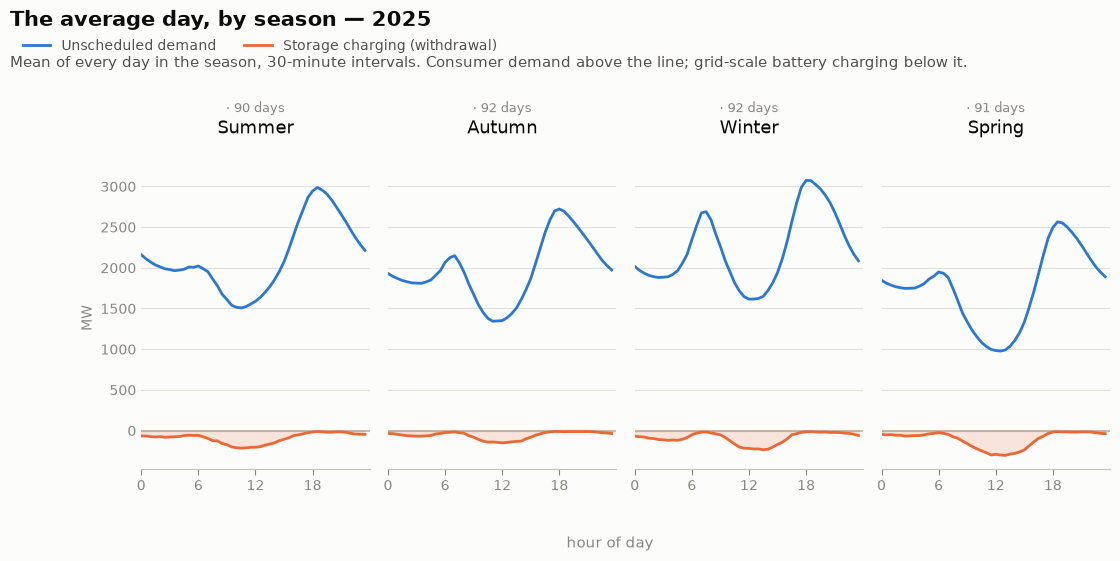

In [8]:
# ── Chart 1: average day shape by season ─────────────────────────────────────
SEASON_ORDER = ["Summer", "Autumn", "Winter", "Spring"]
MIN_DAYS = 30          # below this, an "average day" is not meaningful

days = d30.groupby("season")["date"].nunique()
seasons = [s for s in SEASON_ORDER if days.get(s, 0) >= MIN_DAYS]
print("days per season:", days.to_dict())
print("plotted:", seasons, " dropped:", [s for s in SEASON_ORDER if s not in seasons])

prof = (d30.groupby(["season", "tod_min"])[["unscheduled_demand_mw", "withdrawal_mw"]]
        .mean().reset_index())

fig, axes = plt.subplots(1, len(seasons), sharey=True, figsize=(12.5, 5.6))
axes = np.atleast_1d(axes)

for ax, s in zip(axes, seasons):
    p = prof[prof.season == s].sort_values("tod_min")
    hrs = p.tod_min / 60
    ax.plot(hrs, p.unscheduled_demand_mw, color=BLUE, linewidth=2,
            label="Unscheduled demand", zorder=3)
    ax.fill_between(hrs, 0, p.withdrawal_mw, color=ORANGE, alpha=0.16, zorder=2)
    ax.plot(hrs, p.withdrawal_mw, color=ORANGE, linewidth=2,
            label="Storage charging (withdrawal)", zorder=3)
    ax.axhline(0, color=AXIS, linewidth=1.5, zorder=1)
    ax.set_xlim(0, 24)
    ax.set_xticks([0, 6, 12, 18])
    ax.set_title(s, fontsize=13, color=INK, pad=24)
    ax.text(0.5, 1.17, f"· {days[s]} days", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=9.5, color=MUTED)

axes[0].set_ylabel("MW", color=MUTED)

style(fig, axes, f"The average day, by season — {YEAR}",
      "Mean of every day in the season, 30-minute intervals. "
      "Consumer demand above the line; grid-scale battery charging below it.")

# One shared legend rather than one per panel; "hour of day" likewise stays
# centred beneath all panels instead of repeating under each one.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.02, 0.88),
           ncol=2, frameon=False, labelcolor=INK_2, fontsize=10)
fig.text(0.5, 0.02, "hour of day", ha="center", fontsize=10.5, color=MUTED)

fig.subplots_adjust(top=0.70, bottom=0.16, wspace=0.08)
plt.show()

In [9]:
# ── Chart 1 in numbers: when and how high each feature of the average day sits ──
WINDOWS = {                      # hour-of-day search window for each feature
    "overnight trough": (0, 5.5, "min"),
    "morning peak":     (4, 10, "max"),
    "midday trough":    (8, 16, "min"),
    "evening peak":     (15, 23.5, "max"),
}

def hhmm(h):
    return f"{int(h):02d}:{round(h % 1 * 60):02d}"

rows = []
for s in seasons:
    p = prof[prof.season == s].set_index(prof[prof.season == s].tod_min / 60)
    for name, (h0, h1, how) in WINDOWS.items():
        x = p.loc[h0:h1, "unscheduled_demand_mw"]
        h = x.idxmin() if how == "min" else x.idxmax()
        rows.append(dict(season=s, feature=name, time=hhmm(h), mw=x[h]))
    w = p["withdrawal_mw"]
    rows.append(dict(season=s, feature="peak charging", time=hhmm(w.idxmin()), mw=-w.min()))
    rows.append(dict(season=s, feature="mean charging 00–06", time="", mw=-w.loc[0:5.5].mean()))
    rows.append(dict(season=s, feature="mean charging 17–21", time="", mw=-w.loc[17:20.5].mean()))
kp = pd.DataFrame(rows)

features = list(kp.feature.unique())
print("MW (charging shown as positive):")
print(kp.pivot(index="feature", columns="season", values="mw")
      .reindex(index=features, columns=seasons).round(0).to_string())
print("\nTime of day:")
print(kp[kp.time != ""].pivot(index="feature", columns="season", values="time")
      .reindex(index=[f for f in features if not f.startswith("mean")], columns=seasons).to_string())

demand = kp[kp.feature.isin(WINDOWS)].groupby("feature").mw
spread = demand.max() - demand.min()
print("\nSpread across seasons (demand features):")
print(pd.DataFrame({"range_mw": spread, "range_pct_of_mean": spread / demand.mean() * 100})
      .reindex(list(WINDOWS)).round(0).to_string())

# Caveat for the charging panel: the battery fleet grew through the year, so the
# seasons are not like-for-like. Monthly charging energy makes that visible.
monthly_gwh = -d30.groupby("month").withdrawal_mw.sum() * 0.5 / 1000
print(f"\nCharging energy by month, {YEAR} (GWh):")
print(monthly_gwh.round(1).to_string())
print(f"December / January: {monthly_gwh[12] / monthly_gwh[1]:.1f}x")

MW (charging shown as positive):
season               Summer  Autumn  Winter  Spring
feature                                            
overnight trough     1965.0  1809.0  1881.0  1747.0
morning peak         2022.0  2149.0  2690.0  1949.0
midday trough        1507.0  1343.0  1615.0   978.0
evening peak         2987.0  2722.0  3074.0  2565.0
peak charging         216.0   151.0   236.0   305.0
mean charging 00–06    71.0    54.0    99.0    54.0
mean charging 17–21    21.0    13.0    21.0    26.0

Time of day:
season           Summer Autumn Winter Spring
feature                                     
overnight trough  03:30  03:30  02:30  02:30
morning peak      06:00  07:00  07:30  06:00
midday trough     10:30  11:00  12:00  12:30
evening peak      18:30  18:00  18:00  18:30
peak charging     10:30  12:00  13:30  13:00

Spread across seasons (demand features):
                  range_mw  range_pct_of_mean
feature                                      
overnight trough     218.0          

### Findings

Numbers are from the cell above (2025, 30-minute intervals).

#### Unscheduled Demand
- Demand follows a two-peak, two-trough daily cycle in every season: an overnight trough (02:30–03:30), a morning peak (06:00–07:30), a midday trough (10:30–12:30) and an evening peak (18:00–18:30).
- The evening peak is the daily maximum in every season (2,565–3,074 MW), and the midday trough is the daily minimum (978–1,615 MW), lower than the overnight trough.
- The morning peak varies most in absolute terms across seasons: 1,949 MW in Spring to 2,690 MW in Winter, a 741 MW range. In Summer it is barely a peak, only ~60 MW above the overnight level.
- The overnight trough is the most stable feature, at 1,747–1,965 MW (a 218 MW range, 12% of its mean).
- Relative to its level, the midday trough is the most season-sensitive feature (a 637 MW range, 47% of its mean), and is deepest in Spring (978 MW). This is consistent with rooftop PV suppressing grid demand in the middle of the day.
- Timing follows daylight: the morning peak arrives later in Autumn and Winter (07:00–07:30 vs 06:00), and the midday trough comes earliest in Summer (10:30), possibly because cooling load starts to build before noon.
- Spring has the steepest afternoon ramp: demand climbs ~1,590 MW in six hours, from the 12:30 trough to the 18:30 peak.

#### Storage Charging
- Charging is concentrated around the middle of the day and tracks the midday demand trough. It is strongest between 10:30 (Summer) and 13:30 (Winter).
- A smaller, flat overnight charging band runs from 00:00 to 06:00, averaging 54–99 MW, and is strongest in Winter. It is a plateau rather than a peak.
- Charging is low but not zero across the evening peak (13–26 MW on average, 17:00–21:00). This dataset only records charging; battery *discharge* does not appear here, so low charging does not by itself show that batteries are discharging.

> **Caveat — the charging panel is not a like-for-like seasonal comparison.** Charging energy grew 3.4× within 2025, from 37 GWh in January to 124 GWh in December, as the battery fleet expanded (see the Chart 3 numbers). Later seasons therefore look stronger partly because they come later in the year. *Summer* also mixes Jan–Feb 2025 with Dec 2025. Read the panel for the *shape* of the daily charging pattern, not for differences in magnitude between seasons.

### Implication
- [placeholder]

### 2. One week, at full 5-minute resolution

Averaging hides what makes storage interesting — how sharply it moves. This keeps every 5-minute
reading and narrows the window to a week instead.

`ANCHOR` is the day of 2025's lowest unscheduled demand (386 MW). Change it to look at any other
week: `2025-01-20` is the annual demand peak (4,454 MW), `2025-12-26` the deepest charging day.

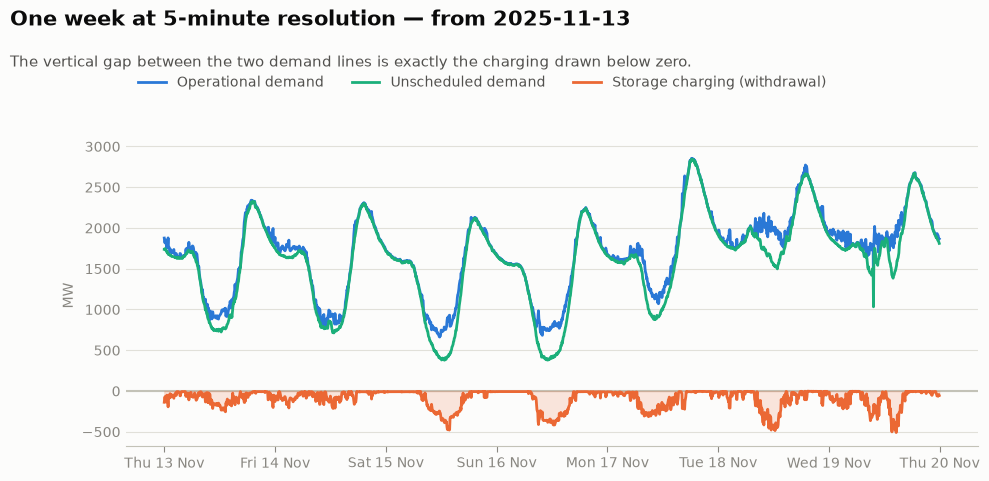

In [10]:
# ── Chart 2: one week in 5-minute detail ─────────────────────────────────────
ANCHOR = pd.Timestamp("2025-11-16")     # lowest unscheduled demand of 2025
start  = ANCHOR - pd.Timedelta(days=3)
wk = d05[(d05.ts >= start) & (d05.ts < start + pd.Timedelta(days=7))]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(wk.ts, wk.operational_demand_mw, color=BLUE, linewidth=2,
        label="Operational demand", zorder=3)
ax.plot(wk.ts, wk.unscheduled_demand_mw, color=AQUA, linewidth=2,
        label="Unscheduled demand", zorder=3)
ax.fill_between(wk.ts, 0, wk.withdrawal_mw, color=ORANGE, alpha=0.16, zorder=2)
ax.plot(wk.ts, wk.withdrawal_mw, color=ORANGE, linewidth=2,
        label="Storage charging (withdrawal)", zorder=3)
ax.axhline(0, color=AXIS, linewidth=1.5, zorder=1)

ax.set_ylabel("MW", color=MUTED)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

style(fig, ax, f"One week at 5-minute resolution — from {start.date()}",
      "The vertical gap between the two demand lines is exactly the charging drawn below zero.")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.14), ncol=3,
          frameon=False, labelcolor=INK_2, fontsize=10)

fig.subplots_adjust(top=0.72, bottom=0.14)
plt.show()

In [11]:
# ── Chart 2 in numbers: what shapes each day of the week ─────────────────────
from scipy import stats
from wa_data import load_dpv

# Rooftop PV for the same week: a cloudy day shows up as low DPV energy and a
# shallow midday trough, whatever day of the week it is.
dpv = load_dpv(raw='../data/raw')
wkd = wk.merge(dpv, on="ts", how="left")
print("Chart 2 week, per day:")
print(wkd.groupby("date").agg(
    day=("ts", lambda t: t.iloc[0].strftime("%a")),
    uod_min_mw=("unscheduled_demand_mw", "min"),
    uod_max_mw=("unscheduled_demand_mw", "max"),
    od_at_uod_min_mw=("operational_demand_mw", lambda s: s[wkd.loc[s.index, "unscheduled_demand_mw"].idxmin()]),
    dpv_gwh=("dpv_mw", lambda s: s.sum() / 12 / 1000),
    charging_gwh=("withdrawal_mw", lambda s: -s.sum() / 12 / 1000),
).round(2).to_string())

# Whole-year check: is there a Tue–Thu effect, or only a weekday/weekend one?
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = d30.groupby("date").agg(dow=("dow", "first"), month=("month", "first"),
                                mean_mw=("unscheduled_demand_mw", "mean"),
                                min_mw=("unscheduled_demand_mw", "min"),
                                peak_mw=("unscheduled_demand_mw", "max"))
by_dow = daily.groupby("dow")[["mean_mw", "min_mw", "peak_mw"]].mean().round(0)
by_dow.index = DOW
print(f"\nDaily unscheduled demand by day of week, {YEAR} (MW):")
print(by_dow.to_string())

groups = {"Tue–Thu vs Mon/Fri": (daily.dow.isin([1, 2, 3]), daily.dow.isin([0, 4])),
          "weekday vs weekend": (daily.dow < 5, daily.dow >= 5)}
for label, (a, b) in groups.items():
    x, y = daily.loc[a, "mean_mw"], daily.loc[b, "mean_mw"]
    p = stats.ttest_ind(x, y, equal_var=False).pvalue
    print(f"{label:20s} {x.mean():5.0f} vs {y.mean():5.0f} MW   diff {x.mean() - y.mean():+4.0f}   Welch p = {p:.2g}")

# The one-interval spike visible on Wed 19 Nov: the largest 5-minute moves of the year
steps = d05.assign(step=d05.unscheduled_demand_mw.diff())
print(f"\nLargest 5-minute drops in unscheduled demand, {YEAR}:")
print(steps.nsmallest(3, "step")[["ts", "unscheduled_demand_mw", "step"]].round(0).to_string(index=False))
spike = steps.loc[steps.step.idxmin(), "ts"]
print("\nAround the largest drop:")
print(wkd[(wkd.ts >= spike - pd.Timedelta("10min")) & (wkd.ts <= spike + pd.Timedelta("10min"))]
      [["ts", "operational_demand_mw", "unscheduled_demand_mw", "withdrawal_mw", "dpv_mw"]].to_string(index=False))

Chart 2 week, per day:
            day  uod_min_mw  uod_max_mw  od_at_uod_min_mw  dpv_gwh  charging_gwh
date                                                                            
2025-11-13  Thu      724.17     2326.39            958.54    16.92          1.81
2025-11-14  Fri      712.81     2299.36            847.44    16.26          1.43
2025-11-15  Sat      378.95     2121.31            768.40    16.85          2.61
2025-11-16  Sun      379.15     2243.29            763.30    17.02          2.67
2025-11-17  Mon      876.16     2844.09           1129.03    17.05          2.23
2025-11-18  Tue     1498.20     2666.37           1944.70    10.86          2.46
2025-11-19  Wed     1032.86     2672.99           1251.59    12.74          2.63

Daily unscheduled demand by day of week, 2025 (MW):
     mean_mw  min_mw  peak_mw
Mon   2073.0  1333.0   2989.0
Tue   2092.0  1364.0   2929.0
Wed   2065.0  1298.0   2908.0
Thu   2090.0  1347.0   2948.0
Fri   2038.0  1330.0   2797.0
Sat   1882.0  1

### Findings

- The deepest charging coincides with the midday troughs in unscheduled demand: batteries charge when grid demand is lowest. The 5-minute view makes this much clearer than the seasonal averages.
- The gap between operational and unscheduled demand is *by definition* the charging (Operational demand = Unscheduled demand − Withdrawal), so a larger gap on some days is the same observation as higher charging, not a separate finding. What it does show is that **charging lifts the operational demand floor**: when unscheduled demand fell to 379 MW on Sun 16 Nov, operational demand was 763 MW.
- The weekend (Sat 15 – Sun 16 Nov) has the deepest troughs of the week (~379 MW vs 713–876 MW on sunny weekdays), with near-identical rooftop PV output (~17 GWh/day). The difference is lower weekend consumption, not more sunshine.
- The higher demand on Tue 18 – Wed 19 Nov is weather, not a day-of-week effect. Rooftop PV fell to 10.9 and 12.7 GWh (vs ~17 GWh on the sunny days), so the midday trough largely failed to form (Tuesday's minimum was 1,498 MW).
- Across all of 2025 there is **no Tue–Thu effect**: those days average 2,082 MW against 2,056 MW for Mon/Fri (Welch p = 0.52). The real calendar effect is **weekday vs weekend**: weekends average ~193 MW (9%) lower (p < 0.001), with midday minimums ~265 MW lower.
- The sharp one-interval dip on Wed 19 Nov at 09:40 is likely a data artefact. Unscheduled demand drops 476 MW (the largest 5-minute drop of 2025) and recovers the next interval, and the rooftop PV estimate spikes by ~620 MW for a single interval right after. Worth excluding or flagging in any modelling.

### Implication


### 3. Carpet plots — every interval of the year at once

No aggregation, no window: one column per day, one row per time of day, magnitude as colour.
Seasonal drift reads left-to-right; the daily cycle reads top-to-bottom.

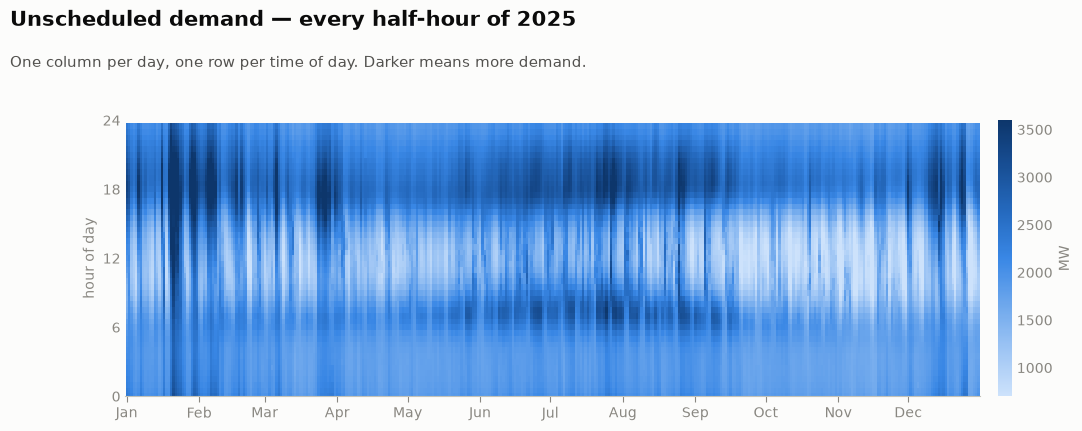

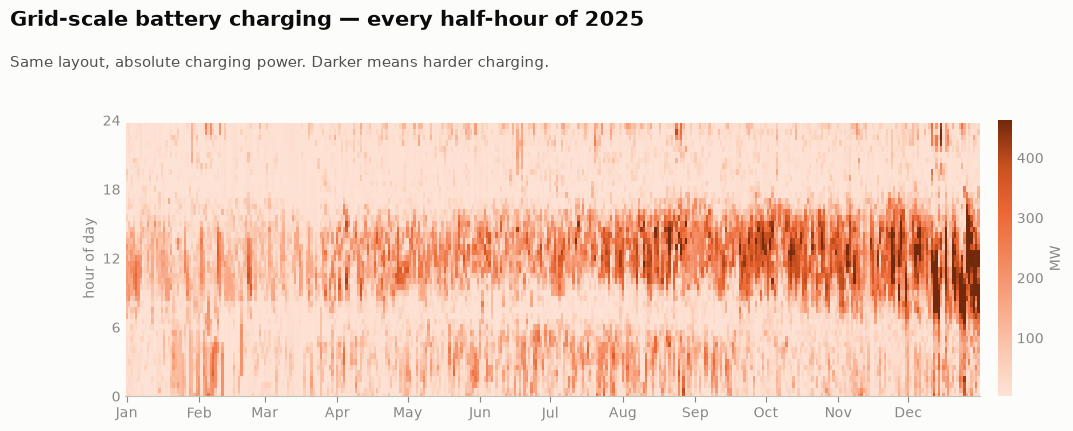

In [12]:
# ── Chart 3: carpet plots ────────────────────────────────────────────────────
def carpet(frame, col, title, subtitle, ramp, transform=None, unit="MW", figsize=(11, 4.6)):
    v = frame[col] if transform is None else transform(frame[col])
    piv = (frame.assign(_v=v)
           .pivot_table(index="tod_min", columns="date", values="_v", aggfunc="mean")
           .sort_index())
    # Clip the colour range to the 1st-99th percentile: a handful of extreme
    # intervals otherwise compress the ramp and wash out the daily structure.
    lo, hi = np.nanpercentile(piv.values.astype(float), [1, 99])
    cmap = LinearSegmentedColormap.from_list(f"{col}_ramp", ramp)

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(piv.columns, piv.index / 60, piv.values,
                          cmap=cmap, vmin=lo, vmax=hi, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02, fraction=0.05)
    cbar.set_label(unit, color=MUTED)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=MUTED, length=0)

    ax.set_ylabel("hour of day", color=MUTED)
    ax.set_yticks([0, 6, 12, 18, 24])
    ax.set_ylim(0, 24)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    style(fig, ax, title, subtitle)
    ax.grid(False)  # a heatmap already carries every interval; gridlines add nothing
    fig.subplots_adjust(top=0.74, bottom=0.14, right=0.96)
    return fig


carpet(d30, "unscheduled_demand_mw",
       f"Unscheduled demand — every half-hour of {YEAR}",
       "One column per day, one row per time of day. Darker means more demand.",
       RAMP_BLUE)
plt.show()

carpet(d30, "withdrawal_mw",
       f"Grid-scale battery charging — every half-hour of {YEAR}",
       "Same layout, absolute charging power. Darker means harder charging.",
       RAMP_ORANGE, transform=lambda s: s.abs())
plt.show()

In [13]:
# ── Chart 3 in numbers: fleet growth, the demand floor, and the extreme days ──
# Charging energy by month across the whole record. Oct 2023 starts at 08:00 on
# the 1st and Sep 2026 holds only its first 8 hours, so treat those as partial.
allm = df_agg.assign(year=df_agg.ts.dt.year, month=df_agg.ts.dt.month)
print("Charging energy by month (GWh):")
print((-allm.pivot_table(index="year", columns="month", values="withdrawal_mw", aggfunc="sum")
       * 0.5 / 1000).round(0).to_string())

# Where in the day the extra charging goes, month by month
BLOCKS = pd.cut(d30.hour, [-1, 5, 8, 15, 21, 23], labels=["00–06", "06–09", "09–16", "16–22", "22–24"])
print(f"\nMean charging by time of day, {YEAR} (MW):")
print((-d30.assign(block=BLOCKS)
       .pivot_table(index="month", columns="block", values="withdrawal_mw", aggfunc="mean", observed=True))
      .round(0).to_string())

# Charging lifts the operational demand floor above the unscheduled one
lo = d30.loc[d30.unscheduled_demand_mw.idxmin()]
print(f"\nLowest unscheduled demand of {YEAR}: {lo.unscheduled_demand_mw:.0f} MW at {lo.ts}, "
      f"operational demand {lo.operational_demand_mw:.0f} MW, charging {-lo.withdrawal_mw:.0f} MW")
print(f"Lowest operational demand of {YEAR}: {d30.operational_demand_mw.min():.0f} MW")
low = d30.unscheduled_demand_mw < 1000
print(f"Mean charging when unscheduled demand < 1,000 MW: {-d30.loc[low, 'withdrawal_mw'].mean():.0f} MW "
      f"({low.sum()} intervals) vs {-d30.withdrawal_mw.mean():.0f} MW overall")

# The days the carpet shows as the lightest and darkest columns
fmt = lambda t: t.assign(day=[DOW[d] for d in t.dow]).drop(columns="dow").round(0).to_string()
print(f"\nLowest 8 days by daily minimum:\n{fmt(daily.nsmallest(8, 'min_mw'))}")
print(f"\nHighest 8 days by daily peak:\n{fmt(daily.nlargest(8, 'peak_mw'))}")

Charging energy by month (GWh):
month     1      2      3     4      5      6      7      8     9     10    11     12
year                                                                                 
2023     NaN    NaN    NaN   NaN    NaN    NaN    NaN    NaN   NaN   6.0   5.0    8.0
2024    12.0   12.0   14.0  13.0   14.0    9.0    8.0   17.0  24.0  33.0  32.0   42.0
2025    37.0   39.0   30.0  47.0   53.0   55.0   67.0   82.0  72.0  78.0  87.0  124.0
2026   137.0  113.0  127.0  88.0  113.0  147.0  150.0  143.0   1.0   NaN   NaN    NaN

Mean charging by time of day, 2025 (MW):
block  00–06  06–09  09–16  16–22  22–24
month                                   
1       47.0   44.0   92.0   16.0   18.0
2       67.0   48.0   97.0   17.0   29.0
3       34.0   31.0   80.0   14.0   17.0
4       51.0   35.0  143.0   18.0   29.0
5       76.0   27.0  140.0   17.0   39.0
6       87.0   36.0  135.0   27.0   39.0
7      103.0   26.0  174.0   27.0   42.0
8      108.0   32.0  226.0   38.0   48.0


### Findings

Numbers are from the cell above.

#### Unscheduled Demand
- The light midday low-demand band is widest in the long-daylight months (roughly Oct–Feb) and narrows in winter, following day length and rooftop PV.
- The band is lightest and most consistent in **Spring** (Sep–Nov). All 8 of the year's lowest-demand days are weekends between late September and late December; the lowest was Sun 16 Nov (386 MW).
- In Summer the band is repeatedly broken by dark vertical stripes: hot days on which demand stays high all day. 7 of the 8 highest-peak days fall between January and early March, led by 4,454 MW on Mon 20 Jan, about 1,470 MW above the Summer average evening peak. The average-day view in Chart 1 hides these days entirely.
- Winter shows dark bands at both the morning (~07:00) and evening (~18:00) peaks, consistent with heating load.

#### Storage Charging
- Charging intensifies and widens steadily through the year. This is **battery fleet growth, not seasonality**: monthly charging energy was 8–17 GWh through August 2024, reached 37 GWh in January 2025 and 124 GWh in December 2025, and has run at 88–150 GWh/month in 2026.
- The extra charging also spreads into the morning. Mean charging between 06:00 and 09:00 rose from 44 MW in January to 225 MW in December. The two months have similar day length, so daylight cannot explain the difference.
- An overnight charging band (00:00–06:00) is strongest from June to August (87–108 MW) and returns in December (98 MW). Winter is likely driven by the smaller midday solar surplus to charge from; December by the larger fleet.
- Charging is concentrated in the lowest-demand hours: when unscheduled demand is below 1,000 MW, charging averages 307 MW, against 88 MW overall. This lifts the operational demand floor, so the year's lowest operational demand (680 MW) sits well above the lowest unscheduled demand (386 MW).